# Steane EC — explicit CNOT-level Pauli tracker for non-Markovian logical noise

[[7,1,3]] Steane code, simulated as **Pauli frames on the 7 data qubits + 7 ancilla qubits per extraction**, propagated through transversal CNOTs using the standard Heisenberg rules.

**Rec structure**: `Wait — EC`. Two consecutive Recs = `Wait — EC — Wait — EC`. Each EC = Z-syndrome extraction (`|0̄⟩` ancilla, `CX(D, anc)`, `M`) followed by X-syndrome extraction (`|+̄⟩` ancilla, `CX(anc, D)`, `MX`); 6-bit syndrome combined and the Hamming-decoded correction applied to data.

**Noise locations** (each is a `WaitNoise` — X with prob `p_x`, Z with prob `p_z`, mutex by default; flip `correlated_xz=True` to allow Y):

| Location | what it is | controlled by |
|---|---|---|
| Wait | per data qubit, between ECs | `WaitNoise(p_x, p_z)` argument to `simulate_recs` |
| ancilla_prep | per ancilla qubit, after `|0̄⟩`/`|+̄⟩` prep | `EC_NOISE.ancilla_prep` |
| cnot_data | per data qubit, at each CNOT block | `EC_NOISE.cnot_data` |
| cnot_anc | per ancilla qubit, at each CNOT block | `EC_NOISE.cnot_anc` |
| meas | pre-measurement Pauli on ancilla | `EC_NOISE.meas` |
| recovery | per data qubit, after Hamming correction | `EC_NOISE.recovery` |

**Case 1** (data-only noise, perfect EC): set `EC_NOISE = ECNoise()`. The explicit CNOT tracker reduces *exactly* to the abstract `compute_syndrome + corrections[s]` lookup (verified in `rec._selftest` T6).

**Case 2** (ancilla qubits also prone to error): set the relevant sub-fields. Errors on ancilla propagate **back onto the data** through the CNOTs — e.g. an ancilla Z error during the Z-extraction propagates as a data Z via `Z_anc → Z_anc·Z_D` under `CX(D, anc)`. The tracker handles this exactly.

**Notebook flow**:
1. Module selftests.
2. Quick view of the Pauli-tracker output.
3. Parameters (including `EC_NOISE` toggle).
4. **Experiment A** — single-Rec transition tensor `T[s_in, L, s_out]`, `λ₂` of `P(s_out | s_in)`.
5. **Experiment B** — bootstrap CIs on `I(L₂; L₁)`, `I(s₂; s₁)`, `I(L₂; s₁ | L₁)`, `I(L₂; L₁ | s₁)`.
6. **`P(L₂ | L₁)` 4×4 panel** — conditional matrix, joint, and joint − product.
7. Sweep over p — log-log MI plot.
8. Save raw shot data.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from nonmarkov_steane.steane_code import build_steane_code, _selftest as steane_code_selftest
from nonmarkov_steane.noise_model import WaitNoise, ECNoise, _selftest as noise_model_selftest
from nonmarkov_steane.rec import (
    simulate_recs, syndrome_batch, logical_class_batch,
    _selftest as rec_selftest,
)
from nonmarkov_steane.simulation import run_single_rec, run_two_recs, _selftest as simulation_selftest
from nonmarkov_steane.diagnostics import (
    entropy_mm, mutual_info, conditional_mutual_info, bootstrap_ci,
    _selftest as diagnostics_selftest,
)
from nonmarkov_steane.experiments import (
    run_experiment_a, run_experiment_b, print_experiment_b_table,
)

PLOTS_DIR = 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True)
print('imports OK')

imports OK


## 1. Module selftests

In [2]:
steane_code_selftest()
print()
noise_model_selftest()
print()
rec_selftest()
print()
simulation_selftest()
print()
diagnostics_selftest()

steane_code._selftest passed: StabilizerCode('[[7,1,3]]', n=7, r=6, n_syndromes=64)
  generator_pairs_commute                        = 15
  logicals_commute_with_generators               = 6
  logicals_anticommute                           = 1
  n_syndromes                                    = 64
  weight1_paulis_have_weight_le_1_correction     = 21
  identity_for_zero_syndrome                     = 1

noise_model._selftest passed:
  mutex_p_x_rate                           = 0.0499
  mutex_p_z_rate                           = 0.0502
  mutex_no_simultaneous_XZ                 = True
  indep_p_y_rate                           = 0.002482
  mutex_validates_p_x_plus_p_z_le_1        = True
  ECNoise_perfect_default                  = True

rec._selftest passed:
  T1_zero_noise_clean_recovery                   = True
  T2_single_X_corrected_to_identity              = 7
  T3a_vectorized_syndrome_matches                = 200
  T3b_vectorized_logical_class_matches           = 4
  T4_p_pos_produ

{'T1_independent_MI_near_zero': np.float64(6e-05),
 'T2_perfect_corr_MI_eq_H_X': (np.float64(2.00002), np.float64(2.00002)),
 'T3_Markov_chain_CMI_near_zero': np.float64(-5e-05),
 'T4_bootstrap_CI_brackets_point': (1.9999, 2.0, 2.0)}

## 2. Quick view of the Pauli tracker output

A small two-Rec sample at p > 0 to inspect the structured array.

In [3]:
arr = run_two_recs(s0=0, p=0.05, n_shots=12, seed=42)
print('dtype:', arr.dtype)
print()
for shot in arr:
    print(f"  s_in={shot['s_in']:2d}  s_1={shot['s_1']:2d}  s_2={shot['s_2']:2d}  "
          f"L1={'IXYZ'[shot['L1']]}  L2={'IXYZ'[shot['L2']]}")

dtype: [('s_in', '<i4'), ('s_1', '<i4'), ('s_2', '<i4'), ('L1', 'i1'), ('L2', 'i1')]

  s_in= 0  s_1=24  s_2=55  L1=I  L2=X
  s_in= 0  s_1= 0  s_2= 8  L1=I  L2=I
  s_in= 0  s_1=32  s_2= 0  L1=I  L2=I
  s_in= 0  s_1= 1  s_2=32  L1=I  L2=I
  s_in= 0  s_1= 0  s_2= 0  L1=I  L2=I
  s_in= 0  s_1= 0  s_2=34  L1=I  L2=I
  s_in= 0  s_1= 0  s_2= 0  L1=I  L2=I
  s_in= 0  s_1= 5  s_2=13  L1=I  L2=X
  s_in= 0  s_1= 0  s_2= 0  L1=I  L2=I
  s_in= 0  s_1= 2  s_2= 5  L1=I  L2=I
  s_in= 0  s_1=24  s_2= 0  L1=I  L2=I
  s_in= 0  s_1= 0  s_2= 5  L1=I  L2=I


## 3. Parameters

In [ ]:
# --- *** CHANGE INPUTS HERE *** ---
P_SINGLE     = 0.02       # depolarizing-like rate for the single-Rec transition tensor
N_SHOTS_A    = 200_000    # per s_in for Experiment A
N_SHOTS_B    = 200_000    # for Experiment B
N_BOOTSTRAP  = 100        # bootstrap resamples per CI
SWEEP_PS     = np.array([0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1])
SEED         = 1234

# ---- EC noise toggle (case 1 vs case 2) ----
# case 1 (data-only noise, perfect EC): EC_NOISE = ECNoise()
# case 2 (ancilla qubits also noisy):   EC_NOISE = case2_ec_noise(p_anc)
def case2_ec_noise(p_anc, correlated_xz=False):
    """Same X/Z mutex noise on ancilla prep and pre-measurement.
    Toggle additional locations by passing more WaitNoise sub-fields."""
    return ECNoise(
        ancilla_prep=WaitNoise(p_x=p_anc, p_z=p_anc, correlated_xz=correlated_xz),
        meas       =WaitNoise(p_x=p_anc, p_z=p_anc, correlated_xz=correlated_xz),
        # cnot_data, cnot_anc, recovery left at WaitNoise() (= zero) for v1.
    )

EC_NOISE = ECNoise()                # case 1 (default)
# EC_NOISE = case2_ec_noise(0.005)  # uncomment for case 2
# ----------------------------------

print(f"Experiment A: p = {P_SINGLE}, n_shots = {N_SHOTS_A} per s_in (× 64 syndromes)")
print(f"Experiment B: n_shots = {N_SHOTS_B}, n_bootstrap = {N_BOOTSTRAP}")
print(f"p sweep: {SWEEP_PS.tolist()}")
print(f"EC noise perfect? {EC_NOISE.is_perfect}")

## 4. Experiment A — Single-Rec transition tensor

For each `s_in ∈ {0, ..., 63}` we sample `N_SHOTS_A` shots of one Rec
(`Wait — EC`) and accumulate the joint counts `T[s_in, L, s_out]`.
Two derived quantities:

- `P(L | s_in)` — 64 × 4 matrix.
- `P(s_out | s_in)` — 64 × 64 stochastic matrix; its second-largest
  eigenvalue (in absolute value) is `lambda_2`. A non-zero `lambda_2`
  indicates the syndrome process has memory beyond a "rank-1" iid
  phenomenological model.

In [ ]:
import time
t0 = time.time()
res_a = run_experiment_a(p=P_SINGLE, n_shots=N_SHOTS_A, seed=SEED, ec_noise=EC_NOISE)
print(f'elapsed: {time.time() - t0:.1f}s')
print(f'lambda_2 = {res_a.lambda_2:.6f}  (largest eigenvalue is 1 by construction)')
print(f'mean P(L=I | s_in) over s_in: {res_a.P_L_given_sin[:, 0].mean():.4f}')
print(f'P(L=I | s_in=0) = {res_a.P_L_given_sin[0, 0]:.4f}')

saved: plots/experiment_A_p0.02_N200000.png


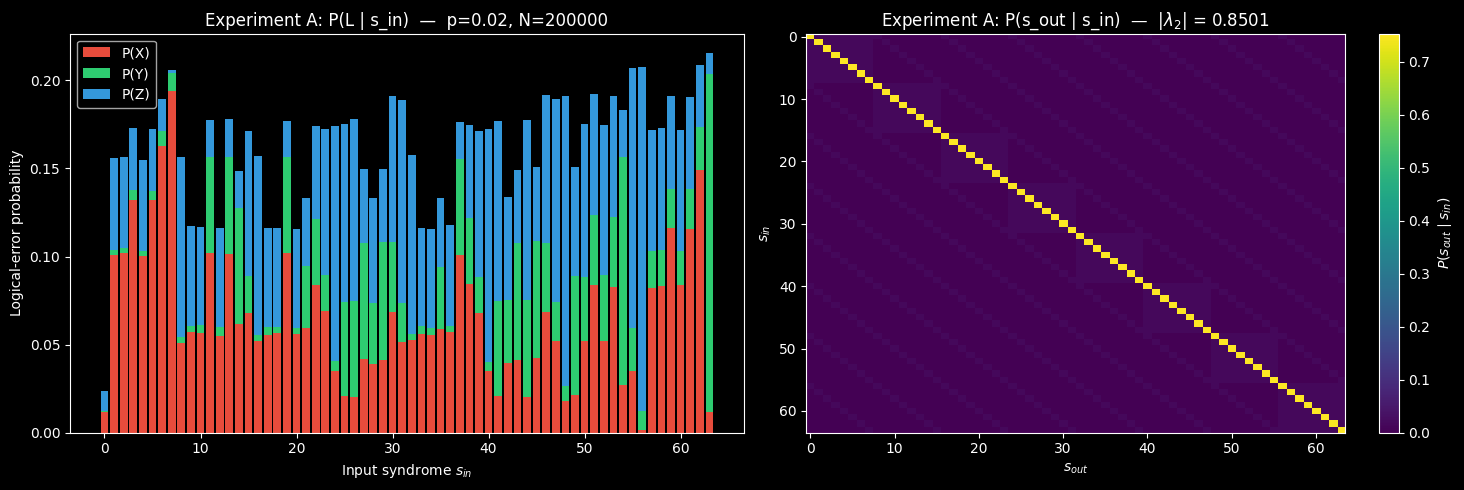

In [6]:
# Plot: stacked P(L|s_in) bar chart + heatmap of P(s_out|s_in)
LOGICAL_NAMES = ['I', 'X', 'Y', 'Z']
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Stacked bar of P(X), P(Y), P(Z) per s_in (omit P(I) since it's 1 - rest)
n_syn = 64
x = np.arange(n_syn)
ax = axes[0]
ax.bar(x, res_a.P_L_given_sin[:, 1], label='P(X)', color='#e74c3c')
ax.bar(x, res_a.P_L_given_sin[:, 2],
       bottom=res_a.P_L_given_sin[:, 1], label='P(Y)', color='#2ecc71')
ax.bar(x, res_a.P_L_given_sin[:, 3],
       bottom=res_a.P_L_given_sin[:, 1] + res_a.P_L_given_sin[:, 2],
       label='P(Z)', color='#3498db')
ax.set_xlabel(r'Input syndrome $s_{in}$')
ax.set_ylabel('Logical-error probability')
ax.set_title(f'Experiment A: P(L | s_in)  —  p={P_SINGLE}, N={N_SHOTS_A}')
ax.legend()

# (b) Heatmap of P(s_out | s_in)
ax = axes[1]
im = ax.imshow(res_a.P_sout_given_sin, vmin=0, vmax=res_a.P_sout_given_sin.max(),
               cmap='viridis', aspect='auto')
plt.colorbar(im, ax=ax, label=r'$P(s_{out} \mid s_{in})$')
ax.set_xlabel(r'$s_{out}$')
ax.set_ylabel(r'$s_{in}$')
ax.set_title(f'Experiment A: P(s_out | s_in)  —  $|\\lambda_2|$ = {res_a.lambda_2:.4f}')

plt.tight_layout()
fname = os.path.join(PLOTS_DIR, f'experiment_A_p{P_SINGLE:g}_N{N_SHOTS_A}.png')
fig.savefig(fname, dpi=150, bbox_inches='tight')
print(f'saved: {fname}')
plt.show()

## 5. Experiment B — Two-Rec correlations & sufficient-statistic tests

Bootstrap CIs at the chosen `p`. Reads:
- `I(L_2 ; L_1) > 0` ⇒ logical errors are correlated across consecutive Recs.
- `I(s_2 ; s_1) > 0` ⇒ syndromes carry memory.
- `I(L_2 ; s_1 | L_1) ≈ 0` ⇒ given `L_1`, `s_1` adds no info — **`L_1` is the sufficient statistic** for predicting `L_2`.
- `I(L_2 ; L_1 | s_1) > 0` ⇒ given `s_1`, `L_1` still informative — `s_1` alone is **not** sufficient.

In [ ]:
P_B = 0.02   # change to inspect at a different p

t0 = time.time()
res_b = run_experiment_b(p=P_B, n_shots=N_SHOTS_B,
                         seed=SEED, n_bootstrap=N_BOOTSTRAP,
                         ec_noise=EC_NOISE)
print(f'elapsed: {time.time() - t0:.1f}s')
print_experiment_b_table(res_b)

## 5b. Conditional `P(L_2 | L_1)` matrix

The 4×4 conditional matrix at the chosen `P_B`:

- **Rows = L_1**, **cols = L_2** — read along a row to see the distribution of L_2 given a specific L_1.
- Three panels: `P(L_2 | L_1)`, joint `P(L_1, L_2)`, and the difference from the Markovian-product reference `P(L_1) · P(L_2)`. The third panel is exactly zero iff L_1 and L_2 are independent — its non-zero structure exposes which `(L_1, L_2)` transitions are over- or under-represented.

In [ ]:
LOGICAL_NAMES = ['I', 'X', 'Y', 'Z']

# Pull a fresh batch at P_B with the active EC_NOISE so the panel reflects
# whatever case (1 or 2) was selected in the parameter cell.
out_panel = run_two_recs(s0=0, p=P_B, n_shots=N_SHOTS_B,
                         ec_noise=EC_NOISE, seed=SEED)
L1_arr = out_panel['L1']
L2_arr = out_panel['L2']

joint_counts = np.zeros((4, 4), dtype=np.int64)
for l1 in range(4):
    for l2 in range(4):
        joint_counts[l1, l2] = int(((L1_arr == l1) & (L2_arr == l2)).sum())

P_joint = joint_counts / joint_counts.sum()
P_L1    = P_joint.sum(axis=1)
P_L2    = P_joint.sum(axis=0)
P_product = np.outer(P_L1, P_L2)
diff_LL = P_joint - P_product

# Conditional P(L2 | L1) = joint / row sum
row_sums = joint_counts.sum(axis=1, keepdims=True).clip(min=1)
P_L2_given_L1 = joint_counts.astype(float) / row_sums

# Print the 4x4 matrix
print(f"P(L_2 | L_1)   at  p = {P_B}, N = {N_SHOTS_B}, "
      f"EC_NOISE.is_perfect = {EC_NOISE.is_perfect}")
print()
print("            " + "  ".join(f"L_2={n:>2s}" for n in LOGICAL_NAMES))
for i, n in enumerate(LOGICAL_NAMES):
    print(f"  L_1 = {n}  " + "  ".join(f"{P_L2_given_L1[i, j]:.5f}"
                                       for j in range(4)))
print()
print(f"  marginals: P(L_1) = {dict(zip(LOGICAL_NAMES, P_L1.round(5)))}")
print(f"             P(L_2) = {dict(zip(LOGICAL_NAMES, P_L2.round(5)))}")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) conditional P(L_2 | L_1)
im0 = axes[0].imshow(P_L2_given_L1, vmin=0, vmax=1, cmap='viridis')
axes[0].set_title(r'$P(L_2 \mid L_1)$')
axes[0].set_xlabel(r'$L_2$'); axes[0].set_ylabel(r'$L_1$')
axes[0].set_xticks(range(4)); axes[0].set_xticklabels(LOGICAL_NAMES)
axes[0].set_yticks(range(4)); axes[0].set_yticklabels(LOGICAL_NAMES)
for i in range(4):
    for j in range(4):
        v = P_L2_given_L1[i, j]
        axes[0].text(j, i, f'{v:.3f}', ha='center', va='center',
                     color='white' if v < 0.6 else 'black', fontsize=9)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# (b) joint
im1 = axes[1].imshow(P_joint, cmap='magma')
axes[1].set_title(r'Joint $P(L_1, L_2)$')
axes[1].set_xlabel(r'$L_2$'); axes[1].set_ylabel(r'$L_1$')
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(LOGICAL_NAMES)
axes[1].set_yticks(range(4)); axes[1].set_yticklabels(LOGICAL_NAMES)
for i in range(4):
    for j in range(4):
        v = P_joint[i, j]
        axes[1].text(j, i, f'{v:.4f}', ha='center', va='center',
                     color='white' if v < P_joint.max() * 0.5 else 'black',
                     fontsize=8)
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# (c) joint - product (zero iff independent)
vmax = max(np.max(np.abs(diff_LL)), 1e-12)
im2 = axes[2].imshow(diff_LL, vmin=-vmax, vmax=vmax, cmap='RdBu_r')
axes[2].set_title(r'$P(L_1, L_2) - P(L_1) P(L_2)$' + '\n(zero iff independent)')
axes[2].set_xlabel(r'$L_2$'); axes[2].set_ylabel(r'$L_1$')
axes[2].set_xticks(range(4)); axes[2].set_xticklabels(LOGICAL_NAMES)
axes[2].set_yticks(range(4)); axes[2].set_yticklabels(LOGICAL_NAMES)
for i in range(4):
    for j in range(4):
        v = diff_LL[i, j]
        axes[2].text(j, i, f'{v:+.4f}', ha='center', va='center',
                     color='black', fontsize=8)
plt.colorbar(im2, ax=axes[2], fraction=0.046)

I_LL = mutual_info(L1_arr, L2_arr)
fig.suptitle(f'L_1 → L_2 correlation panel  —  Steane code, p={P_B}, '
             f'N={N_SHOTS_B}, perfect_EC={EC_NOISE.is_perfect}  '
             f'I(L_1;L_2) = {I_LL:.4f} bits', y=1.02)
plt.tight_layout()

case_tag = 'case1' if EC_NOISE.is_perfect else 'case2'
fname = os.path.join(PLOTS_DIR,
    f'P_L2_given_L1_{case_tag}_p{P_B:g}_N{N_SHOTS_B}.png')
fig.savefig(fname, dpi=150, bbox_inches='tight')
print(f'saved: {fname}')
plt.show()

## 6. Sweep over p — log-log plot of the four MIs

Without bootstrap (point estimates only) for speed.

In [ ]:
N_SWEEP = 200_000
results_sweep = {p: {} for p in SWEEP_PS}

for p in SWEEP_PS:
    out = run_two_recs(s0=0, p=float(p), n_shots=N_SWEEP,
                       ec_noise=EC_NOISE,
                       seed=SEED + int(p * 1e6))
    L1, L2 = out['L1'], out['L2']
    s1, s2 = out['s_1'], out['s_2']
    results_sweep[p]['I_L1L2']        = mutual_info(L1, L2)
    results_sweep[p]['I_s1s2']        = mutual_info(s1, s2)
    results_sweep[p]['I_L2_s1_g_L1']  = conditional_mutual_info(L2, s1, L1)
    results_sweep[p]['I_L2_L1_g_s1']  = conditional_mutual_info(L2, L1, s1)
    print(f"p={p:.4f}  I(L2;L1)={results_sweep[p]['I_L1L2']:.5f}  "
          f"I(s2;s1)={results_sweep[p]['I_s1s2']:.5f}  "
          f"I(L2;s1|L1)={results_sweep[p]['I_L2_s1_g_L1']:.5f}  "
          f"I(L2;L1|s1)={results_sweep[p]['I_L2_L1_g_s1']:.5f}")

In [ ]:
def _series(key):
    return np.array([results_sweep[p][key] for p in SWEEP_PS])

I_L1L2       = _series('I_L1L2')
I_s1s2       = _series('I_s1s2')
I_L2_s1_g_L1 = _series('I_L2_s1_g_L1')
I_L2_L1_g_s1 = _series('I_L2_L1_g_s1')

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(SWEEP_PS, np.maximum(I_L1L2, 1e-7), 'o-', color='#c0392b',
          label=r'$I(L_2 ; L_1)$ — corr. logical errors')
ax.loglog(SWEEP_PS, np.maximum(I_s1s2, 1e-7), 's-', color='#2471a3',
          label=r'$I(s_2 ; s_1)$ — corr. syndromes')
ax.loglog(SWEEP_PS, np.maximum(I_L2_L1_g_s1, 1e-7), '^-', color='#8e44ad',
          label=r'$I(L_2 ; L_1 \mid s_1)$ — $s_1$ NOT sufficient')
ax.loglog(SWEEP_PS, np.maximum(I_L2_s1_g_L1, 1e-7), 'v-', color='#16a085',
          label=r'$I(L_2 ; s_1 \mid L_1)$ — $L_1$ IS sufficient')
ax.set_xlabel(r'$p$  (per-qubit X or Z probability per Wait)')
ax.set_ylabel('mutual information [bits]')
case_tag = 'case1 (perfect EC)' if EC_NOISE.is_perfect else 'case2 (ancilla noisy)'
ax.set_title(f'Two-Rec MIs vs p — Steane code, {case_tag}')
ax.grid(alpha=0.3, which='both')
ax.legend()
plt.tight_layout()

short_tag = 'case1' if EC_NOISE.is_perfect else 'case2'
fname = os.path.join(PLOTS_DIR,
    f'mi_sweep_{short_tag}_p{SWEEP_PS[0]:g}-{SWEEP_PS[-1]:g}_N{N_SWEEP}.png')
fig.savefig(fname, dpi=150, bbox_inches='tight')
print(f'saved: {fname}')
plt.show()

## 7. Save raw shot data

Per the spec — saves raw `(s_in, s_1, s_2, L1, L2)` arrays and the sweep summary to `.npz` files for downstream analysis.

In [ ]:
DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)
case_tag = 'case1' if EC_NOISE.is_perfect else 'case2'

# Save Experiment A
fname_a = os.path.join(DATA_DIR,
    f'experiment_A_{case_tag}_p{P_SINGLE:g}_N{N_SHOTS_A}_seed{SEED}.npz')
np.savez_compressed(
    fname_a,
    p=P_SINGLE,
    n_shots=N_SHOTS_A,
    T=res_a.T,
    P_L_given_sin=res_a.P_L_given_sin,
    P_sout_given_sin=res_a.P_sout_given_sin,
    lambda_2=res_a.lambda_2,
)
print(f'saved: {fname_a}')

# Save Experiment B raw shots at the chosen P_B
out_b = run_two_recs(s0=0, p=P_B, n_shots=N_SHOTS_B,
                     ec_noise=EC_NOISE, seed=SEED)
fname_b = os.path.join(DATA_DIR,
    f'experiment_B_raw_{case_tag}_p{P_B:g}_N{N_SHOTS_B}_seed{SEED}.npz')
np.savez_compressed(
    fname_b,
    p=P_B,
    n_shots=N_SHOTS_B,
    s_in=out_b['s_in'],
    s_1=out_b['s_1'],
    s_2=out_b['s_2'],
    L1=out_b['L1'],
    L2=out_b['L2'],
)
print(f'saved: {fname_b}')

# Save sweep summary
fname_sweep = os.path.join(DATA_DIR,
    f'mi_sweep_{case_tag}_N{N_SWEEP}_seed{SEED}.npz')
np.savez_compressed(
    fname_sweep,
    p_values=SWEEP_PS,
    n_shots=N_SWEEP,
    I_L1L2=I_L1L2,
    I_s1s2=I_s1s2,
    I_L2_s1_g_L1=I_L2_s1_g_L1,
    I_L2_L1_g_s1=I_L2_L1_g_s1,
)
print(f'saved: {fname_sweep}')